# **Correlation Study**

## Objectives

* Expand on the cancellation EDA to answer BR1:

    *TCS Hotels wants to understand cancellation patterns, trends and guest behaviour across their 2 Portuguese properties in order to identify risk factors and develop more effective cancellation defence strategies*
* Investigate correlation between features and the target variable `is_canceled` using Pearson, Spearman and PPS to indentify which features carry meaningful predictive signal
* Formally validate hypotheses 1, 2 and 3 using appropriate statistical tests
* Rank features by predictive relationship with the target to inform which engineered features are required

## Inputs

* The dataset as cleaned in the [cleaning notebook](/jupyter_notebooks/04_cleaning.ipynb):

    outputs/datasets/cleaned/HotelBookingsClean.csv

## Outputs

* Relevant correlation/PPS matrices and visualisations
* Statistical test results for H1, H2 and H3
* A ranked features table saved to outputs/correlation/RankedFeatures.csv

## Additional Comments

* ⚠️ TBC ⚠️ 


---

# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

current_dir = os.getcwd()
current_dir

You set a new current directory


'/home/niall/PP4/cancel-protect'

## Load Data

In [3]:
import pandas as pd
df = pd.read_csv("outputs/datasets/cleaned/HotelBookingsClean.csv")
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,0,0,Transient,75.0,0,0


In [4]:
df.shape


(119192, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119192 entries, 0 to 119191
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119192 non-null  object 
 1   is_canceled                     119192 non-null  int64  
 2   lead_time                       119192 non-null  int64  
 3   arrival_date_year               119192 non-null  int64  
 4   arrival_date_month              119192 non-null  object 
 5   arrival_date_week_number        119192 non-null  int64  
 6   arrival_date_day_of_month       119192 non-null  int64  
 7   stays_in_weekend_nights         119192 non-null  int64  
 8   stays_in_week_nights            119192 non-null  int64  
 9   adults                          119192 non-null  int64  
 10  children                        119192 non-null  int64  
 11  babies                          119192 non-null  int64  
 12  meal            

* Since the category conversion of `is_repeated_guest`, `agent` and `company` was not preserved in the saving process, re-specify dtype

In [6]:
categorical_list = ["is_repeated_guest", "agent", "company"]
for col in categorical_list:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119192 entries, 0 to 119191
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119192 non-null  object  
 1   is_canceled                     119192 non-null  int64   
 2   lead_time                       119192 non-null  int64   
 3   arrival_date_year               119192 non-null  int64   
 4   arrival_date_month              119192 non-null  object  
 5   arrival_date_week_number        119192 non-null  int64   
 6   arrival_date_day_of_month       119192 non-null  int64   
 7   stays_in_weekend_nights         119192 non-null  int64   
 8   stays_in_week_nights            119192 non-null  int64   
 9   adults                          119192 non-null  int64   
 10  children                        119192 non-null  int64   
 11  babies                          119192 non-null  int64   
 12  me

---

## Split Feature Groups

* The dataset contains 3 distinct feature groups:
    1. The target variable (binary) ["is_canceled"]
    2. Numeric Features
    3. Categorical Features
    4. Temporal Features

In [7]:
target = ["is_canceled"]

In [25]:
numeric_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

In [26]:
categorical_features = [
    "hotel",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "is_repeated_guest",
    "agent",
    "company",
]

In [10]:
temporal_features = [
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month"
]

In [27]:
numeric_correlation_df = pd.concat([df[target], df[numeric_features]], axis=1)
numeric_correlation_df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,0,342,0,0,2,0,0,0,0,3,0,0.0,0,0
1,0,737,0,0,2,0,0,0,0,4,0,0.0,0,0
2,0,7,0,1,1,0,0,0,0,0,0,75.0,0,0
3,0,13,0,1,1,0,0,0,0,0,0,75.0,0,0
4,0,14,0,2,2,0,0,0,0,0,0,98.0,0,1


---

## Pearson Correlation with Target

In [28]:
pearson_df = numeric_correlation_df.corr(method="pearson")
pearson_df

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.292638,-0.001427,0.025419,0.060927,0.004636,-0.034143,0.110171,-0.057348,-0.144810,0.054332,0.047979,-0.197122,-0.234786
lead_time,0.292638,1.000000,0.085767,0.166695,0.125971,-0.037814,-0.021565,0.086084,-0.073606,0.002291,0.170103,-0.067062,-0.117664,-0.095771
stays_in_weekend_nights,-0.001427,0.085767,1.000000,0.494108,0.108880,0.045640,0.020271,-0.012757,-0.042887,0.050157,-0.054389,0.054353,-0.019066,0.073222
stays_in_week_nights,0.025419,0.166695,0.494108,1.000000,0.111413,0.043971,0.023149,-0.013965,-0.048887,0.080018,-0.002009,0.071214,-0.025655,0.068837
adults,0.060927,0.125971,0.108880,0.111413,1.000000,0.036651,0.024979,-0.007751,-0.128842,-0.047641,-0.009109,0.293151,0.018941,0.151229
children,0.004636,-0.037814,0.045640,0.043971,0.036651,1.000000,0.026726,-0.024801,-0.021115,0.050547,-0.033357,0.342258,0.057269,0.081820
babies,-0.034143,-0.021565,0.020271,0.023149,0.024979,0.026726,1.000000,-0.008007,-0.006984,0.091195,-0.011358,0.033785,0.041751,0.106920
previous_cancellations,0.110171,0.086084,-0.012757,-0.013965,-0.007751,-0.024801,-0.008007,1.000000,0.152571,-0.027262,0.005939,-0.069216,-0.018654,-0.048501
previous_bookings_not_canceled,-0.057348,-0.073606,-0.042887,-0.048887,-0.128842,-0.021115,-0.006984,0.152571,1.000000,0.011933,-0.009417,-0.075878,0.047358,0.037774
booking_changes,-0.144810,0.002291,0.050157,0.080018,-0.047641,0.050547,0.091195,-0.027262,0.011933,1.000000,-0.011917,0.026786,0.067325,0.055009


In [29]:
import numpy as np

def heatmap_mask(df, threshold):
    mask = np.zeros_like(df, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    mask[abs(df) < threshold] = True
    return mask


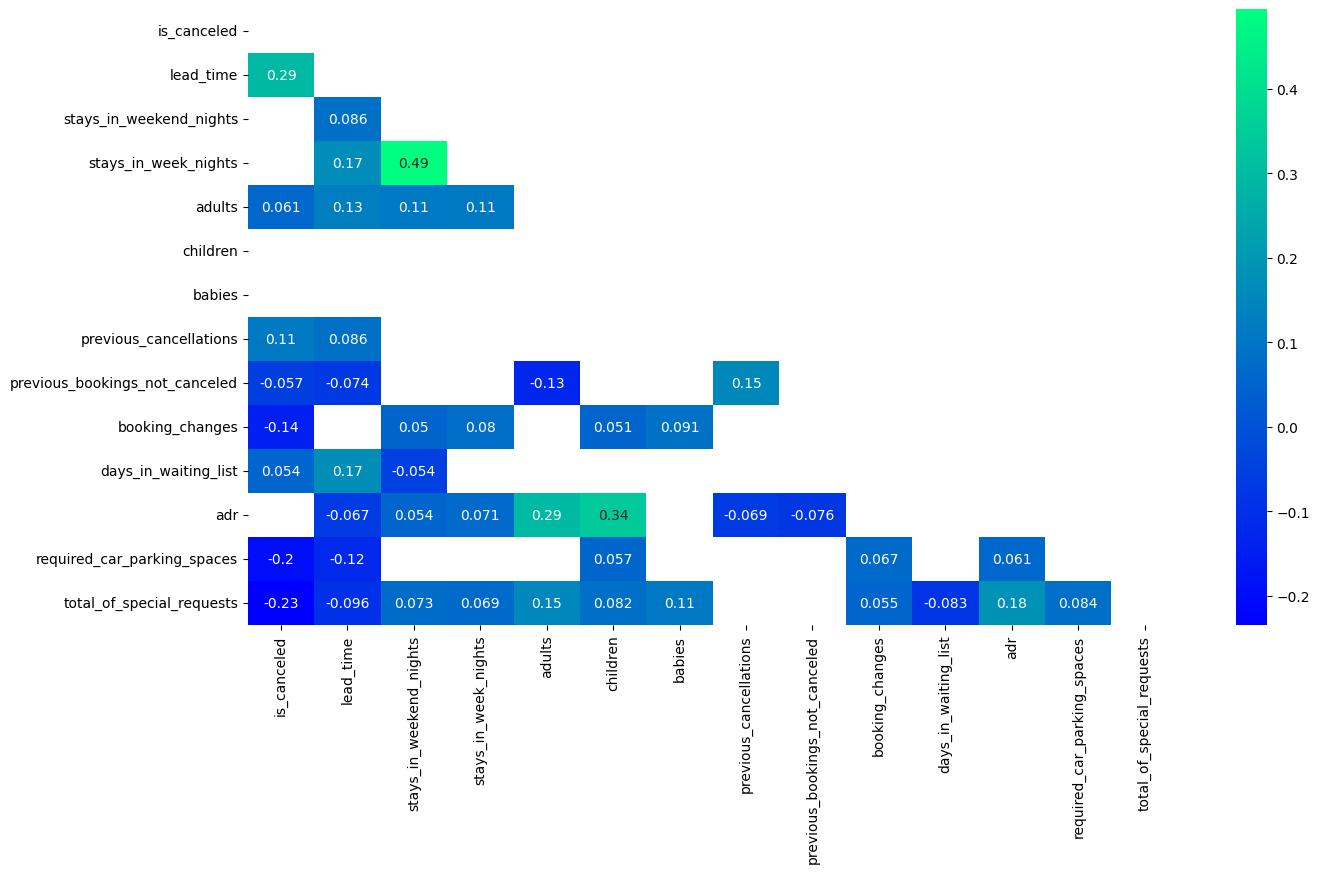

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 8))

sns.heatmap(
    pearson_df, 
    mask=(heatmap_mask(pearson_df, 0.05)), 
    annot=True,
    cmap="winter",
    ax=ax)

plt.show()

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
